# CakapKarier AI - Career Match Experiment

Notebook ini mendokumentasikan pekerjaan AI Engineer untuk sistem **career readiness and job matching** CakapKarier AI. Fokusnya adalah menyiapkan data final dari tim Data Science menjadi dataset siap model, membangun model Deep Learning TensorFlow, mengevaluasi performa, mengekspor artefak siap produksi, dan menyediakan kontrak inference yang bisa dipakai oleh tim fullstack.

Notebook ini tidak diposisikan sebagai satu-satunya sumber logic produksi. Logic utama tetap berada di modul Python (`pipelines/`, `services/career-match/`, dan `shared/schemas/`) agar eksperimen dapat direproduksi, diuji, dan dipakai langsung oleh backend tanpa harus menjalankan notebook.

Ringkasan update eksperimen:

- Dataset utama memakai `all_data_final.csv` dari tim Data Science dan data dictionary pendukung.
- Preprocessing AI hanya melakukan transformasi untuk kebutuhan model, bukan mengulang cleaning data mentah.
- Label training dibuat dengan weak supervision berbasis pasangan kandidat-lowongan sintetis: `match` untuk kandidat yang memenuhi requirement lowongan dan `not_match` untuk kandidat lintas role atau underqualified.
- Model memakai TensorFlow Functional API dengan pendekatan ANN Siamese/Dual Encoder Matching.
- Fitur mandatory project, yaitu skill, pengalaman, dan sertifikasi, dipakai sebagai sinyal utama dalam feature engineering.
- Update v1.4.1 menambahkan normalisasi skill yang lebih rapi, fitur `semantic_similarity`, calibrated readiness score, serta certification completeness boost agar skor readiness lebih representatif terhadap jumlah sertifikasi kandidat.
- Evaluasi menampilkan metrik train, validation, test, classification report, confusion matrix, durasi epoch, dan TensorBoard log.
- Artefak akhir mencakup model `.keras`, SavedModel, katalog lowongan, metadata, metrics, dan kontrak API.

Catatan interpretasi: akurasi model pada test set tinggi karena label training dibangun secara konsisten melalui weak supervision. Untuk MVP, hasil ini valid sebagai pembuktian pipeline AI Engine. Untuk pengembangan berikutnya, kualitas model perlu terus divalidasi dengan manual review, feedback user, atau data outcome nyata dari proses karier.


## 1. Setup Path dan Konfigurasi

Bagian ini menyiapkan path project dan import dependency supaya notebook bisa dijalankan secara konsisten dari beberapa lokasi kerja: root repository, folder `AIEngine`, atau langsung dari folder `notebooks`.

Hal yang dilakukan pada cell setup:

- Mendeteksi lokasi `AIEngine` secara otomatis.
- Menambahkan folder service `career-match/src` ke `sys.path` agar modul inference dapat di-import.
- Menentukan lokasi dataset final Data Science: `data/raw/all_data_final.csv`.
- Menentukan lokasi data dictionary DS: `data/raw/Data_Dictionary.csv`.
- Menentukan folder processed dataset dan model registry.
- Mengatur opsi `RUN_PREPROCESSING` dan `RUN_TRAINING` agar eksperimen bisa dijalankan ulang jika diperlukan.
- Mengatur style visualisasi Matplotlib yang dipakai di seluruh notebook.


In [1]:
from pathlib import Path
import importlib
import json
import sys
from textwrap import wrap

from IPython.display import Image as IPImage, display as ipy_display
import pandas as pd
import matplotlib.pyplot as plt


def find_ai_engine_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if path.name == 'AIEngine' and (path / 'pipelines').exists():
            return path
        candidate = path / 'AIEngine'
        if (candidate / 'pipelines').exists():
            return candidate
    raise RuntimeError('Folder AIEngine tidak ditemukan dari current working directory.')


AIENGINE_ROOT = find_ai_engine_root(Path.cwd())
REPO_ROOT = AIENGINE_ROOT.parent
SERVICE_SRC = AIENGINE_ROOT / 'services' / 'career-match' / 'src'

for path in [AIENGINE_ROOT, SERVICE_SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

importlib.invalidate_caches()

DS_CLEAN_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'all_data_final.csv'
DS_DICTIONARY_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'Data_Dictionary.csv'
RAW_PATHS = [DS_CLEAN_PATH] if DS_CLEAN_PATH.exists() else []
PROCESSED_DIR = AIENGINE_ROOT / 'data' / 'processed' / 'career-match-v1'
MODEL_DIR = AIENGINE_ROOT / 'models' / 'registry' / 'career-match' / 'v1'

# Ubah menjadi True jika ingin menjalankan ulang dari awal.
RUN_PREPROCESSING = False
RUN_TRAINING = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'


def show_figure(fig, output_path=None, width=None, dpi=180):
    # Render figure secara stabil di VS Code/Jupyter meski backend Matplotlib non-interactive.
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
        ipy_display(IPImage(filename=str(output_path), width=width))
    else:
        ipy_display(fig)
    plt.close(fig)


def plot_barh(series, title, xlabel='Count', color='#2563eb'):
    fig, ax = plt.subplots(figsize=(10, 5))
    series.sort_values().plot(kind='barh', color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.tight_layout()
    show_figure(fig)

print('AIENGINE_ROOT =', AIENGINE_ROOT)
print('RAW_PATHS =', RAW_PATHS)
print('MODEL_DIR exists =', MODEL_DIR.exists())



AIENGINE_ROOT = C:\DBS Foundation\CakapKarier AI\AIEngine
RAW_PATHS = [WindowsPath('C:/DBS Foundation/CakapKarier AI/AIEngine/data/raw/all_data_final.csv')]
MODEL_DIR exists = True


## 2. Business Objective

CakapKarier AI bertujuan membantu pengguna memahami kesiapan kerja berdasarkan profil mereka, lalu memberikan rekomendasi role, lowongan relevan, skill gap, dan roadmap pengembangan. Dari sisi AI Engineer, masalah bisnis ini diterjemahkan menjadi **career matching problem**: sistem membandingkan profil kandidat dengan katalog lowongan kerja, kemudian menghasilkan skor kesiapan dan rekomendasi yang dapat dijelaskan.

Model tidak hanya mengejar prediksi `match` atau `not_match`, tetapi juga harus dapat mendukung kebutuhan produk:

- Menentukan role atau lowongan yang paling relevan dengan profil pengguna.
- Mengukur kesiapan pengguna dalam skala yang mudah dipahami frontend, yaitu 0 sampai 100.
- Menjelaskan skill yang sudah sesuai dan skill yang masih perlu ditingkatkan.
- Memberikan roadmap belajar yang praktis untuk mendukung peningkatan kesiapan karier.
- Menyediakan response JSON yang stabil untuk integrasi backend dan frontend.

Checklist AI Engineer yang dipenuhi:

- TensorFlow Functional API untuk model multi-input.
- Custom Layer: `CosineSimilarityLayer` dan `AbsoluteDifferenceLayer`.
- Custom Loss Function: `CareerMatchLoss`.
- Custom Callback: `QualityThresholdCallback`.
- Custom training loop menggunakan `tf.GradientTape`.
- Export model ke `.keras` dan SavedModel.
- Kode inference dan FastAPI service.
- TensorBoard log untuk monitoring training.
- Optional GenAI summary melalui Ollama/OpenAI-compatible API dengan fallback deterministik.


## 3. Raw Dataset Assessment

Bagian ini memvalidasi dataset final dari tim Data Science sebelum dipakai oleh pipeline AI. Dataset yang dipakai adalah `all_data_final.csv` dan data dictionary pendukung `Data_Dictionary.csv`.

Tahap ini bukan untuk mengulang cleaning data mentah, tetapi untuk memastikan data final sudah dapat digunakan oleh model. Validasi yang dilakukan meliputi:

- **Struktur kolom**: memastikan kolom penting seperti `job_title`, `company`, `location`, `description`, `requirements`, dan `skills_text` tersedia.
- **Jumlah data dan sumber data**: melihat total baris dan distribusi sumber data, misalnya Glints dan LinkedIn.
- **Missing value**: mengecek apakah ada kolom penting yang kosong dan berpotensi mengganggu feature extraction.
- **Duplikasi**: memeriksa kemungkinan duplikasi berdasarkan `job_detail` atau informasi lowongan.
- **Distribusi awal**: melihat job title, lokasi, dan panjang teks agar AI Engineer memahami karakteristik data sebelum training.

Output dari tahap ini menjadi dasar keputusan apakah dataset sudah cukup stabil untuk diproses menjadi training-ready dataset. Jika ditemukan masalah besar, catatan ini dapat dikembalikan ke tim Data Science untuk diperbaiki di dataset final.


In [2]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)
raw_df = preprocess_module.load_raw_sources(RAW_PATHS)

raw_summary = {
    'rows': len(raw_df),
    'columns': list(raw_df.columns),
    'source_distribution': raw_df['source'].value_counts().to_dict() if 'source' in raw_df.columns else {},
    'missing_values': raw_df.isna().sum().to_dict(),
    'duplicate_job_detail': int(raw_df.duplicated('job_detail').sum()) if 'job_detail' in raw_df else None,
    'unique_job_titles': int(raw_df['job_title'].nunique()) if 'job_title' in raw_df else None,
}
raw_summary


{'rows': 5859,
 'columns': ['source',
  'source_sheet',
  'source_row_id',
  'job_title',
  'company',
  'location',
  'job_detail',
  'description',
  'requirements',
  'skills_text',
  'skills_clean_text',
  'job_benefits'],
 'source_distribution': {'glints': 5630, 'linkedin': 229},
 'missing_values': {'source': 0,
  'source_sheet': 0,
  'source_row_id': 0,
  'job_title': 0,
  'company': 0,
  'location': 0,
  'job_detail': 0,
  'description': 0,
  'requirements': 0,
  'skills_text': 0,
  'skills_clean_text': 0,
  'job_benefits': 0},
 'duplicate_job_detail': 228,
 'unique_job_titles': 2603}

In [3]:
if DS_DICTIONARY_PATH.exists():
    ds_dictionary = pd.read_csv(DS_DICTIONARY_PATH, encoding='utf-8-sig')
    display(ds_dictionary)
else:
    print('Data dictionary DS belum tersedia di AIEngine/data/raw/Data_Dictionary.csv')


,Kolom,Tipe,Deskripsi,Contoh Nilai,Nilai Khusus / Catatan,Missing Value Policy
0,web_scraper_order,string,ID urutan scraping dari WebScraper.io. Nilainy...,1779164489-1,Bukan primary key. Tidak digunakan untuk anali...,Tidak ada missing value
1,web_scraper_start_url,string,URL halaman daftar lowongan yang menjadi titik...,https://glints.com/id/en/opportunities/jobs/ex...,Satu URL bisa menghasilkan banyak baris. Total...,Tidak ada missing value
2,source,string (kategorikal),Platform asal data lowongan kerja.,Glints | LinkedIn,"Hanya 2 nilai: Glints (5,627 baris) dan Linked...",Tidak ada missing value
3,source_encoded,integer (binary),Label encoding dari kolom source. Siap digunak...,0 | 1,"0 = Glints, 1 = LinkedIn",Tidak ada missing value
4,job_title,string,Nama posisi atau jabatan pekerjaan yang ditawa...,Data Analyst | Software Engineer | It Support,"2,603 nilai unik. Variasi tinggi karena perusa...",Tidak ada missing value
5,company,string,"Nama perusahaan yang membuka lowongan, sudah d...",Pt Gojek Indonesia | Pt Telkom Indonesia,"2,307 perusahaan unik.",Tidak ada missing value
6,location,string,"Lokasi pekerjaan dalam format: Kota/Kabupaten,...","Jakarta Selatan, Dki Jakarta | Kab. Bekasi, Ja...",186 nilai unik. Beberapa baris dari LinkedIn m...,Tidak ada missing value
7,province,string (kategorikal),Nama provinsi yang diekstrak dari kolom location.,Dki Jakarta | Jawa Timur | Jawa Barat,40 nilai unik — PERLU PERHATIAN: sebagian buka...,Tidak ada missing value; nilai tidak diketahui...
8,job_detail,string (URL),URL langsung menuju halaman detail lowongan pe...,https://glints.com/id/opportunities/jobs/data-...,235 baris bernilai 'Not Available' (mayoritas ...,Not Available (jika tidak tersedia)
9,description,string (teks panjang),Deskripsi lengkap pekerjaan termasuk tanggung ...,Bertanggung jawab dalam pengelolaan data perus...,"3,424 nilai unik. Memerlukan preprocessing NLP...",Not Available (jika tidak tersedia)


,source,source_sheet,job_title,company,location,requirements,skills_text
0,glints,,"Engineering Staff (Kawah Ijen, Banyuwangi)",Pt Bobobox Mitra Indonesia,"Kab. Banyuwangi, Jawa Timur",PersyaratanKerja di lokasiPengalaman kurang da...,SkillsPlumbingMaintenance EngineeringElectrica...
1,glints,,Digital Marketing,Tiba Tiba Pindahan,"Jakarta Selatan, Dki Jakarta",PersyaratanHybrid3 - 5 tahun pengalamanMinimal...,SkillsDigital MarketingGoogle AnalyticsGoogle ...
2,glints,,It Network Engineering,Pt Sinar Digital Nusantara,"Bandung, Jawa Barat",PersyaratanKerja di lokasi3 - 5 tahun pengalam...,SkillsCoba lanjut melamar - 1 dari 10 dimiliki...
3,glints,,Senior Full Stack Developer,Mindflex Education Pte. Ltd,"Jakarta Selatan, Dki Jakarta",PersyaratanRemote/Dari rumah5 - 10 tahun penga...,SkillsWordPress DevelopmentMySQLPHPLaravelType...
4,glints,,Technical Support Specialist (L2) Redis,Pt. All Data International,"Jakarta Barat, Dki Jakarta",PersyaratanKerja di lokasi3 - 5 tahun pengalam...,SkillsTechnical SupportNetwork Troubleshooting...


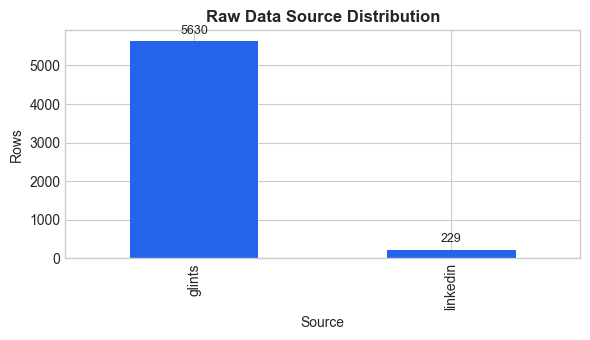

,count
job_title,
Sales Engineer,137
Data Engineer,99
System Analyst,71
Software Engineer,47
It Support,47
Devops Engineer,44
It Business Analyst,40
Ai Engineer,37
It Project Manager,35


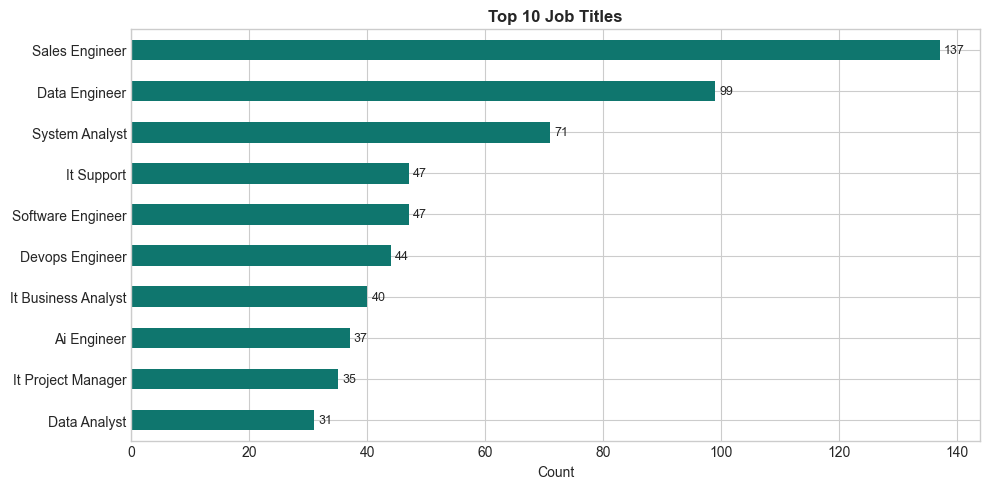

,count
location,
"Jakarta Selatan, Dki Jakarta",1392
"Jakarta Pusat, Dki Jakarta",443
"Jakarta Barat, Dki Jakarta",421
"Surabaya, Jawa Timur",387
"Jakarta Utara, Dki Jakarta",279
"Tangerang, Banten",219
"Kab. Tangerang, Banten",210
"Bandung, Jawa Barat",200
"Kab. Sidoarjo, Jawa Timur",196


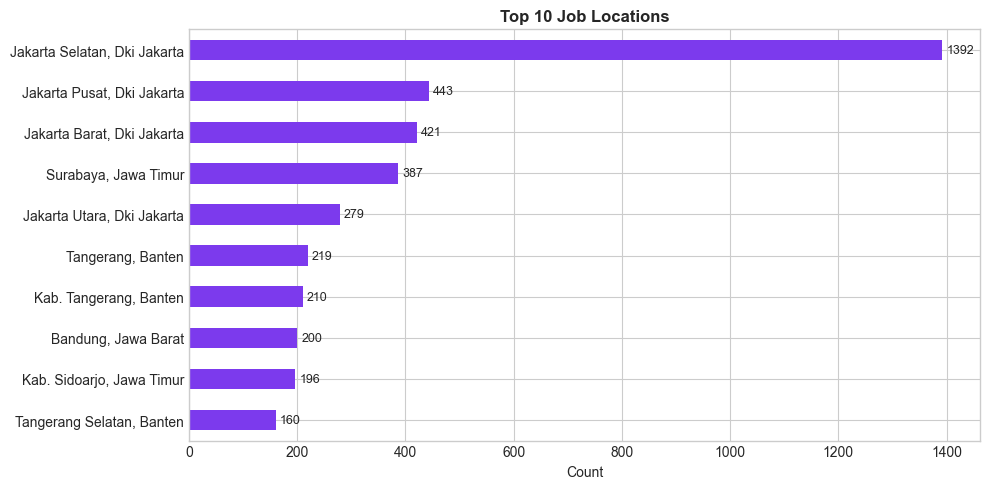

Tidak ada missing value pada dataset raw.


In [4]:
preview_cols = [
    col for col in [
        'source',
        'source_sheet',
        'job_title',
        'company',
        'location',
        'requirements',
        'skills_text',
    ]
    if col in raw_df.columns
]
display(raw_df[preview_cols].head(5))

fig, ax = plt.subplots(figsize=(6, 3.5))
raw_df['source'].value_counts().plot(kind='bar', ax=ax, color='#2563eb')
ax.set_title('Raw Data Source Distribution')
ax.set_xlabel('Source')
ax.set_ylabel('Rows')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
show_figure(fig)

top_titles = raw_df['job_title'].value_counts().head(10)
top_locations = raw_df['location'].value_counts().head(10)
missing_values = raw_df.isna().sum().sort_values(ascending=False)

display(top_titles.rename('count').to_frame())
plot_barh(top_titles, 'Top 10 Job Titles', color='#0f766e')

display(top_locations.rename('count').to_frame())
plot_barh(top_locations, 'Top 10 Job Locations', color='#7c3aed')

non_zero_missing = missing_values[missing_values > 0]
if len(non_zero_missing):
    display(non_zero_missing.rename('missing_count').to_frame())
    plot_barh(non_zero_missing, 'Missing Values by Column', color='#dc2626')
else:
    print('Tidak ada missing value pada dataset raw.')



,description_words,requirements_words,skills_chars
count,5859.00,5859.00,5859.00
mean,161.51,9.19,108.85
std,119.52,2.03,67.84
min,2.00,2.00,11.00
25%,80.00,9.00,63.00
50%,140.00,9.00,95.00
75%,214.00,10.00,135.00
max,1106.00,13.00,893.00


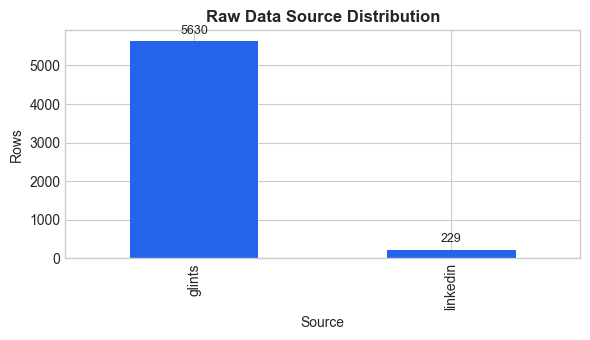

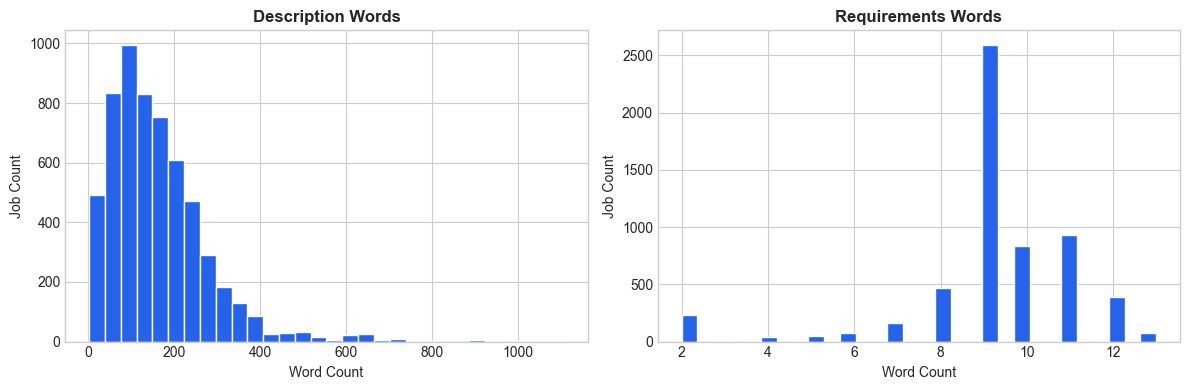

In [5]:
skills_column = 'skills_text' if 'skills_text' in raw_df.columns else None
text_length_df = pd.DataFrame({
    'description_words': raw_df['description'].fillna('').astype(str).str.split().str.len(),
    'requirements_words': raw_df['requirements'].fillna('').astype(str).str.split().str.len(),
    'skills_chars': raw_df[skills_column].fillna('').astype(str).str.len() if skills_column else 0,
})

display(text_length_df.describe().round(2))

axes = text_length_df[['description_words', 'requirements_words']].hist(
    bins=30,
    figsize=(12, 4),
    color='#2563eb',
    edgecolor='white',
)
for ax in axes.flatten():
    ax.set_title(ax.get_title().replace('_', ' ').title())
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Job Count')
plt.tight_layout()
show_figure(fig)



## 4. Preprocessing dan Weak Supervision

Bagian ini adalah **model-specific preprocessing**, bukan cleaning ulang terhadap data mentah. Dataset yang digunakan sudah dibersihkan oleh tim Data Science. Peran AI Engineer pada tahap ini adalah mengubah dataset final tersebut menjadi format yang dapat dipakai oleh model TensorFlow.

Alasan preprocessing tetap diperlukan di sisi AI:

- Model tidak menerima tabel lowongan secara langsung, melainkan membutuhkan input teks dan fitur numerik.
- Kolom seperti skill, pengalaman, pendidikan, dan sertifikasi perlu dinormalisasi menjadi sinyal model yang konsisten.
- Dataset lowongan tidak memiliki label kandidat nyata, sehingga perlu dibentuk pasangan kandidat-lowongan untuk training awal.
- Backend membutuhkan artefak tambahan seperti `jobs_catalog.json`, metadata, dan kontrak fitur agar inference dapat berjalan tanpa notebook.

Proses yang dilakukan:

- **Schema normalization**: menyamakan nama dan format kolom agar pipeline bisa membaca data secara konsisten.
- **Text preparation**: menggabungkan job title, description, requirements, dan skills menjadi `job_text`.
- **Skill normalization**: membersihkan variasi penulisan seperti `NodeJs`, `node js`, `Postgre`, `ReactJS`, dan token scraping yang menempel agar fitur skill lebih akurat.
- **Feature extraction**: mengekstrak skill, pengalaman, pendidikan, sertifikasi, work mode, seniority, dan role family dari data lowongan.
- **Numeric feature engineering**: membentuk fitur `skill_overlap`, `certification_overlap`, `experience_ratio`, `education_match`, `skill_count_ratio`, `missing_skill_ratio`, `seniority_gap`, dan `semantic_similarity`.
- **Semantic similarity**: menghitung cosine similarity dari hashed text embedding kandidat dan lowongan. Fitur ini bersifat self-supervised karena tidak membutuhkan label tambahan, tetapi membantu model menangkap kemiripan konteks teks.
- **Synthetic candidate generation**: membuat profil kandidat sintetis berdasarkan karakteristik lowongan untuk membentuk pasangan training.
- **Weak supervision labeling**: memberi label otomatis berdasarkan aturan yang terkontrol.
- **Train/validation/test split**: membagi data agar evaluasi terpisah dari training.
- **Export processed dataset**: menyimpan dataset siap training ke `data/processed/career-match-v1`.

Strategi label weak supervision:

- **Positive market fit** diberi label `1` atau `match`. Kandidat sintetis dibuat memiliki skill, pengalaman, pendidikan, atau sertifikasi yang selaras dengan kebutuhan lowongan.
- **Negative cross role** diberi label `0` atau `not_match`. Kandidat berasal dari role family berbeda, misalnya profil frontend dibandingkan dengan lowongan data/AI.
- **Negative underqualified** diberi label `0` atau `not_match`. Kandidat berada pada role yang relatif dekat, tetapi skill, pengalaman, atau sertifikasinya sengaja dibuat kurang dari requirement.

Interpretasi untuk presentasi: weak supervision dipakai karena dataset dari lowongan kerja tidak memiliki label kandidat nyata. Pendekatan ini membuat MVP bisa dilatih secara end-to-end, tetapi metriknya harus dibaca sebagai performa terhadap aturan label yang dibangun. Karena itu, manual validation atau review sampel tetap disarankan untuk mengecek apakah aturan label sudah masuk akal secara domain.


In [6]:

importlib.invalidate_caches()
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')
preprocess_module = importlib.reload(preprocess_module)

if RUN_PREPROCESSING or not (PROCESSED_DIR / 'metadata.json').exists():
    preprocess_metadata = preprocess_module.run(
        raw_paths=RAW_PATHS,
        output_dir=PROCESSED_DIR,
        seed=42,
        negatives_per_job=2,
    )
else:
    preprocess_metadata = json.loads((PROCESSED_DIR / 'metadata.json').read_text(encoding='utf-8'))

preprocess_metadata


{'business_questions': ['Role pekerjaan IT apa yang paling sering muncul dari sumber Glints dan LinkedIn?',
  'Skill apa yang paling banyak diminta oleh pasar kerja?',
  'Bagaimana distribusi pengalaman minimum, work mode, dan lokasi lowongan?',
  'Seberapa siap profil kandidat terhadap lowongan berdasarkan skill, pengalaman, dan sertifikasi?'],
 'raw_sources': ['C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\data\\raw\\all_data_final.csv'],
 'source_distribution': {'glints': 5630, 'linkedin': 229},
 'source_rows': 5859,
 'unique_job_titles': 2600,
 'pair_counts': {'train': 12303, 'val': 2637, 'test': 2637},
 'role_family_distribution': {'other-it': 1069,
  'it-support-network': 1031,
  'software-engineering': 926,
  'qa-security': 726,
  'sales-account': 716,
  'data-ai': 709,
  'admin-operations': 441,
  'product-project-business': 188,
  'design-content': 53},
 'work_mode_distribution': {'unknown': 5240,
  'onsite': 323,
  'remote': 203,
  'hybrid': 93},
 'top_locations': {'Jakarta S

,split,rows
0,jobs,5859
1,train_pairs,12303
2,val_pairs,2637
3,test_pairs,2637


,count
role_family,
other-it,1069
it-support-network,1031
software-engineering,926
qa-security,726
sales-account,716
data-ai,709
admin-operations,441
product-project-business,188
design-content,53


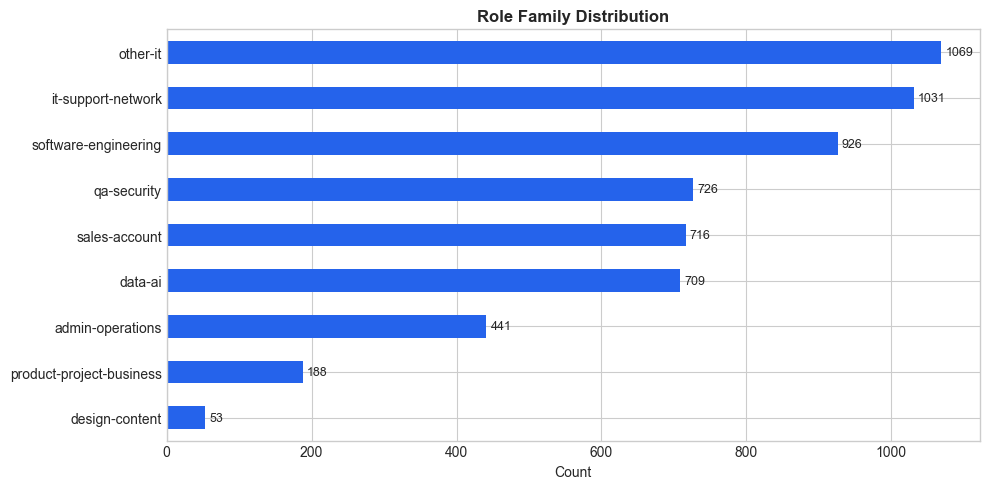

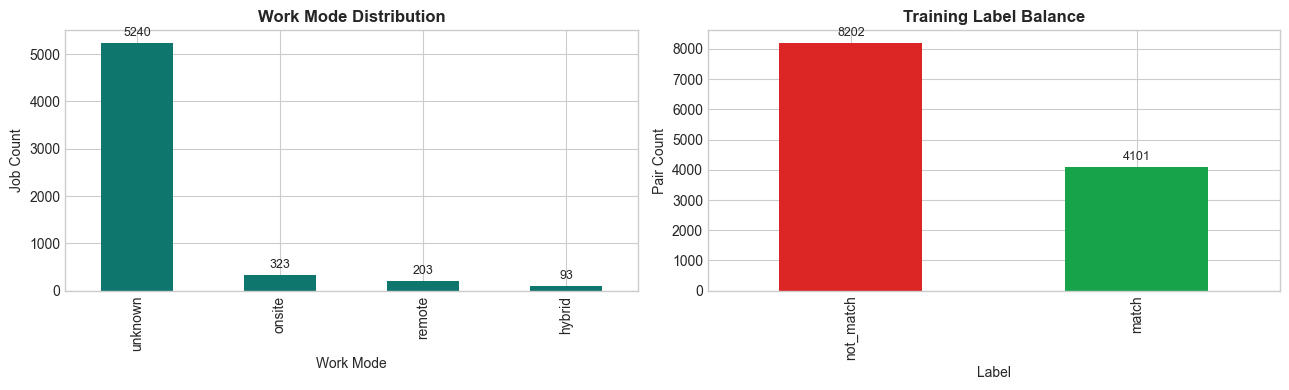

,pair_type,label,count
0,positive_market_fit,1.0,4101
1,negative_underqualified,0.0,4101
2,negative_cross_role,0.0,4101


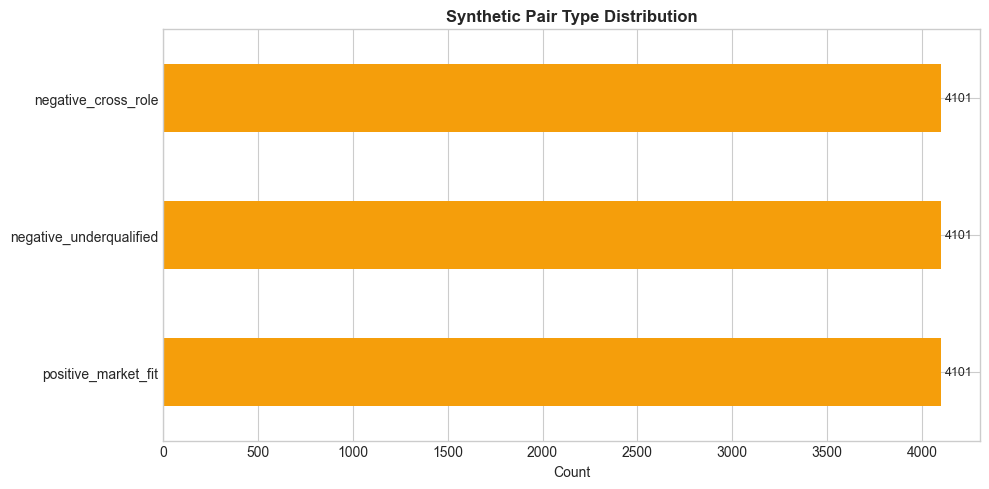

In [7]:
jobs_df = pd.read_csv(PROCESSED_DIR / 'jobs_processed.csv')
train_pairs = pd.read_csv(PROCESSED_DIR / 'train_pairs.csv')
val_pairs = pd.read_csv(PROCESSED_DIR / 'val_pairs.csv')
test_pairs = pd.read_csv(PROCESSED_DIR / 'test_pairs.csv')

processed_summary = pd.DataFrame(
    [
        {'split': 'jobs', 'rows': len(jobs_df)},
        {'split': 'train_pairs', 'rows': len(train_pairs)},
        {'split': 'val_pairs', 'rows': len(val_pairs)},
        {'split': 'test_pairs', 'rows': len(test_pairs)},
    ]
)
display(processed_summary)

role_counts = jobs_df['role_family'].value_counts()
work_mode_counts = jobs_df['work_mode'].value_counts()
pair_type_counts = train_pairs['pair_type'].value_counts()
label_counts = train_pairs['label'].map({0.0: 'not_match', 1.0: 'match'}).value_counts()

display(role_counts.rename('count').to_frame())
plot_barh(role_counts, 'Role Family Distribution', color='#2563eb')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
work_mode_counts.plot(kind='bar', ax=axes[0], color='#0f766e')
axes[0].set_title('Work Mode Distribution')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Job Count')
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

label_counts.plot(kind='bar', ax=axes[1], color=['#dc2626', '#16a34a'])
axes[1].set_title('Training Label Balance')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Pair Count')
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
plt.tight_layout()
show_figure(fig)

display(train_pairs[['pair_type', 'label']].value_counts().rename('count').reset_index())
plot_barh(pair_type_counts, 'Synthetic Pair Type Distribution', color='#f59e0b')


,count
communication,1251
sql,910
testing,857
python,836
excel,740
api,670
communication skills,664
cloud,651
microsoft excel,637
microsoft office,626


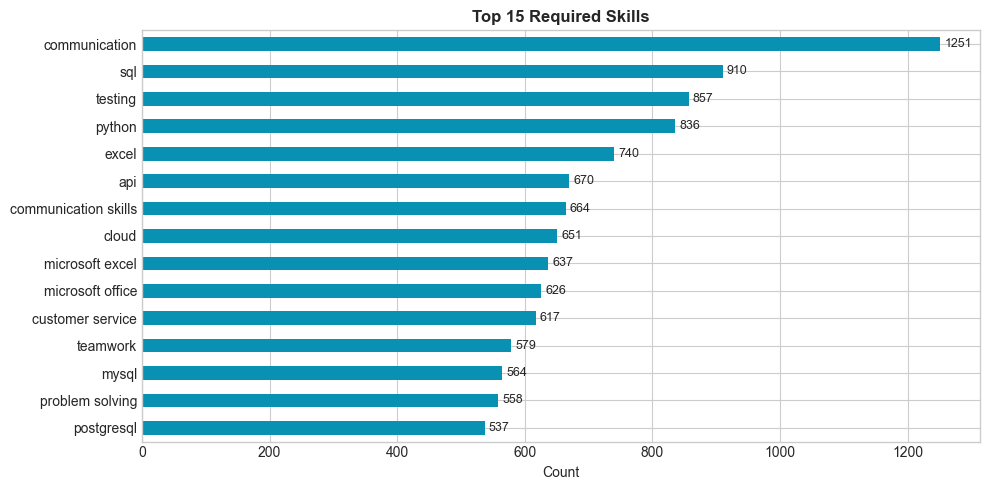

In [8]:
from collections import Counter

skill_counter = Counter()
for value in jobs_df['skills']:
    try:
        skills = json.loads(value) if isinstance(value, str) else value
    except json.JSONDecodeError:
        skills = []
    skill_counter.update(skills)

top_skills = pd.Series(dict(skill_counter.most_common(15)))
display(top_skills.rename('count').to_frame())
plot_barh(top_skills, 'Top 15 Required Skills', color='#0891b2')

## 5. Model Architecture

Model yang digunakan adalah **Deep Learning berbasis ANN dengan pola Siamese/Dual Encoder Matching**. Model ini bukan CNN, RNN, LSTM, GRU, atau Transformer, karena masalah bisnisnya bukan klasifikasi gambar atau prediksi urutan panjang, melainkan membandingkan dua entitas: profil kandidat dan kebutuhan lowongan kerja.

Arsitektur dibuat memakai **TensorFlow Functional API** karena model memiliki tiga input: `candidate_text`, `job_text`, dan `numeric_features`. Functional API membuat hubungan antar-input lebih eksplisit, mudah diekspor ke format produksi, dan kompatibel dengan custom layer.

### Alur Utama Model

1. **Candidate Profile**
   Input ini berasal dari pengguna aplikasi: skill, pengalaman, pendidikan, sertifikasi, minat/bakat, target role, dan lokasi preferensi. Informasi tersebut dinormalisasi menjadi `candidate_text` dan fitur numerik.

2. **Job Catalog Text**
   Input ini berasal dari dataset lowongan final. Job title, description, requirements, dan required skills digabung menjadi `job_text`. Pada inference, satu profil kandidat dibandingkan dengan banyak lowongan di katalog.

3. **Shared Text Encoder**
   `candidate_text` dan `job_text` diproses oleh encoder teks yang sama. Encoder terdiri dari `TextVectorization`, `Embedding`, dan `GlobalAveragePooling1D`. Karena bobot encoder dipakai bersama, representasi kandidat dan lowongan berada pada ruang embedding yang sama.

4. **Pairwise Similarity Custom Layers**
   `CosineSimilarityLayer` mengukur kemiripan arah embedding kandidat-lowongan, sedangkan `AbsoluteDifferenceLayer` membaca jarak absolut antar embedding. Dua layer ini menjadi komponen custom utama untuk membantu model memahami kedekatan profil dan lowongan.

5. **Numeric Readiness Features**
   Model juga menerima delapan fitur numerik: `skill_overlap`, `certification_overlap`, `experience_ratio`, `education_match`, `skill_count_ratio`, `missing_skill_ratio`, `seniority_gap`, dan `semantic_similarity`. Fitur mandatory project, yaitu pengalaman, skill, dan sertifikasi, masuk langsung dalam bagian ini.

6. **Dense Matcher**
   Output similarity dan fitur numerik digabung dengan `Concatenate`, lalu diproses oleh Dense layer dan Dropout. Bagian ini adalah ANN classifier yang mempelajari pola pembeda antara pasangan `match` dan `not_match`.

7. **Sigmoid Match Probability**
   Output model adalah probabilitas 0 sampai 1 dari sigmoid layer. Nilai ini disebut raw model probability dan berguna untuk audit model, tetapi tidak langsung dijadikan skor utama di UI.

8. **Calibrated Readiness Score**
   Service inference menggabungkan raw model probability dengan sinyal yang lebih mudah dijelaskan: skill overlap, sertifikasi, pengalaman, pendidikan, semantic similarity, target role alignment, lokasi, dan kelengkapan evidence pada lowongan. Hasilnya adalah readiness score 0-100 yang lebih stabil untuk profil pengguna nyata.

### Ringkasan Komponen Teknis

| Komponen | Detail Teknis | Fungsi Bisnis |
|---|---|---|
| Text input | `candidate_text`, `job_text` | Membandingkan profil pengguna dengan kebutuhan lowongan |
| Numeric input | 8 readiness and semantic features | Memastikan skill, pengalaman, sertifikasi, pendidikan, dan konteks teks memengaruhi skor |
| Custom layer | `CosineSimilarityLayer`, `AbsoluteDifferenceLayer` | Mengukur kedekatan kandidat-lowongan secara eksplisit |
| Classifier | Dense + Dropout | Mempelajari pola match/not_match dari data training |
| Raw output | Sigmoid probability | Dipakai untuk audit model dan ranking internal |
| Product output | Calibrated readiness score | Dipakai frontend sebagai skor kesiapan dan persentase kecocokan |


In [9]:
model_metadata_path = MODEL_DIR / 'metadata.json'
if model_metadata_path.exists():
    model_metadata = json.loads(model_metadata_path.read_text(encoding='utf-8'))
else:
    model_metadata = {
        'status': 'Model belum ditraining. Jalankan cell training dengan RUN_TRAINING=True.'
    }

model_metadata

{'model_name': 'cakapkarier_career_matcher',
 'version': 'v1',
 'framework': 'TensorFlow/Keras',
 'architecture': 'Functional API dual text encoder plus numeric readiness and semantic similarity features',
 'custom_components': ['CosineSimilarityLayer',
  'AbsoluteDifferenceLayer',
  'CareerMatchLoss',
  'QualityThresholdCallback',
  'tf.GradientTape custom training loop'],
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap',
  'semantic_similarity'],
 'model_path': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\career_match_model.keras',
 'saved_model_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\saved_model',
 'tensorboard_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\tensorboard',
 'evaluation_artifacts': {'classification_report_csv': 'C:\\DB

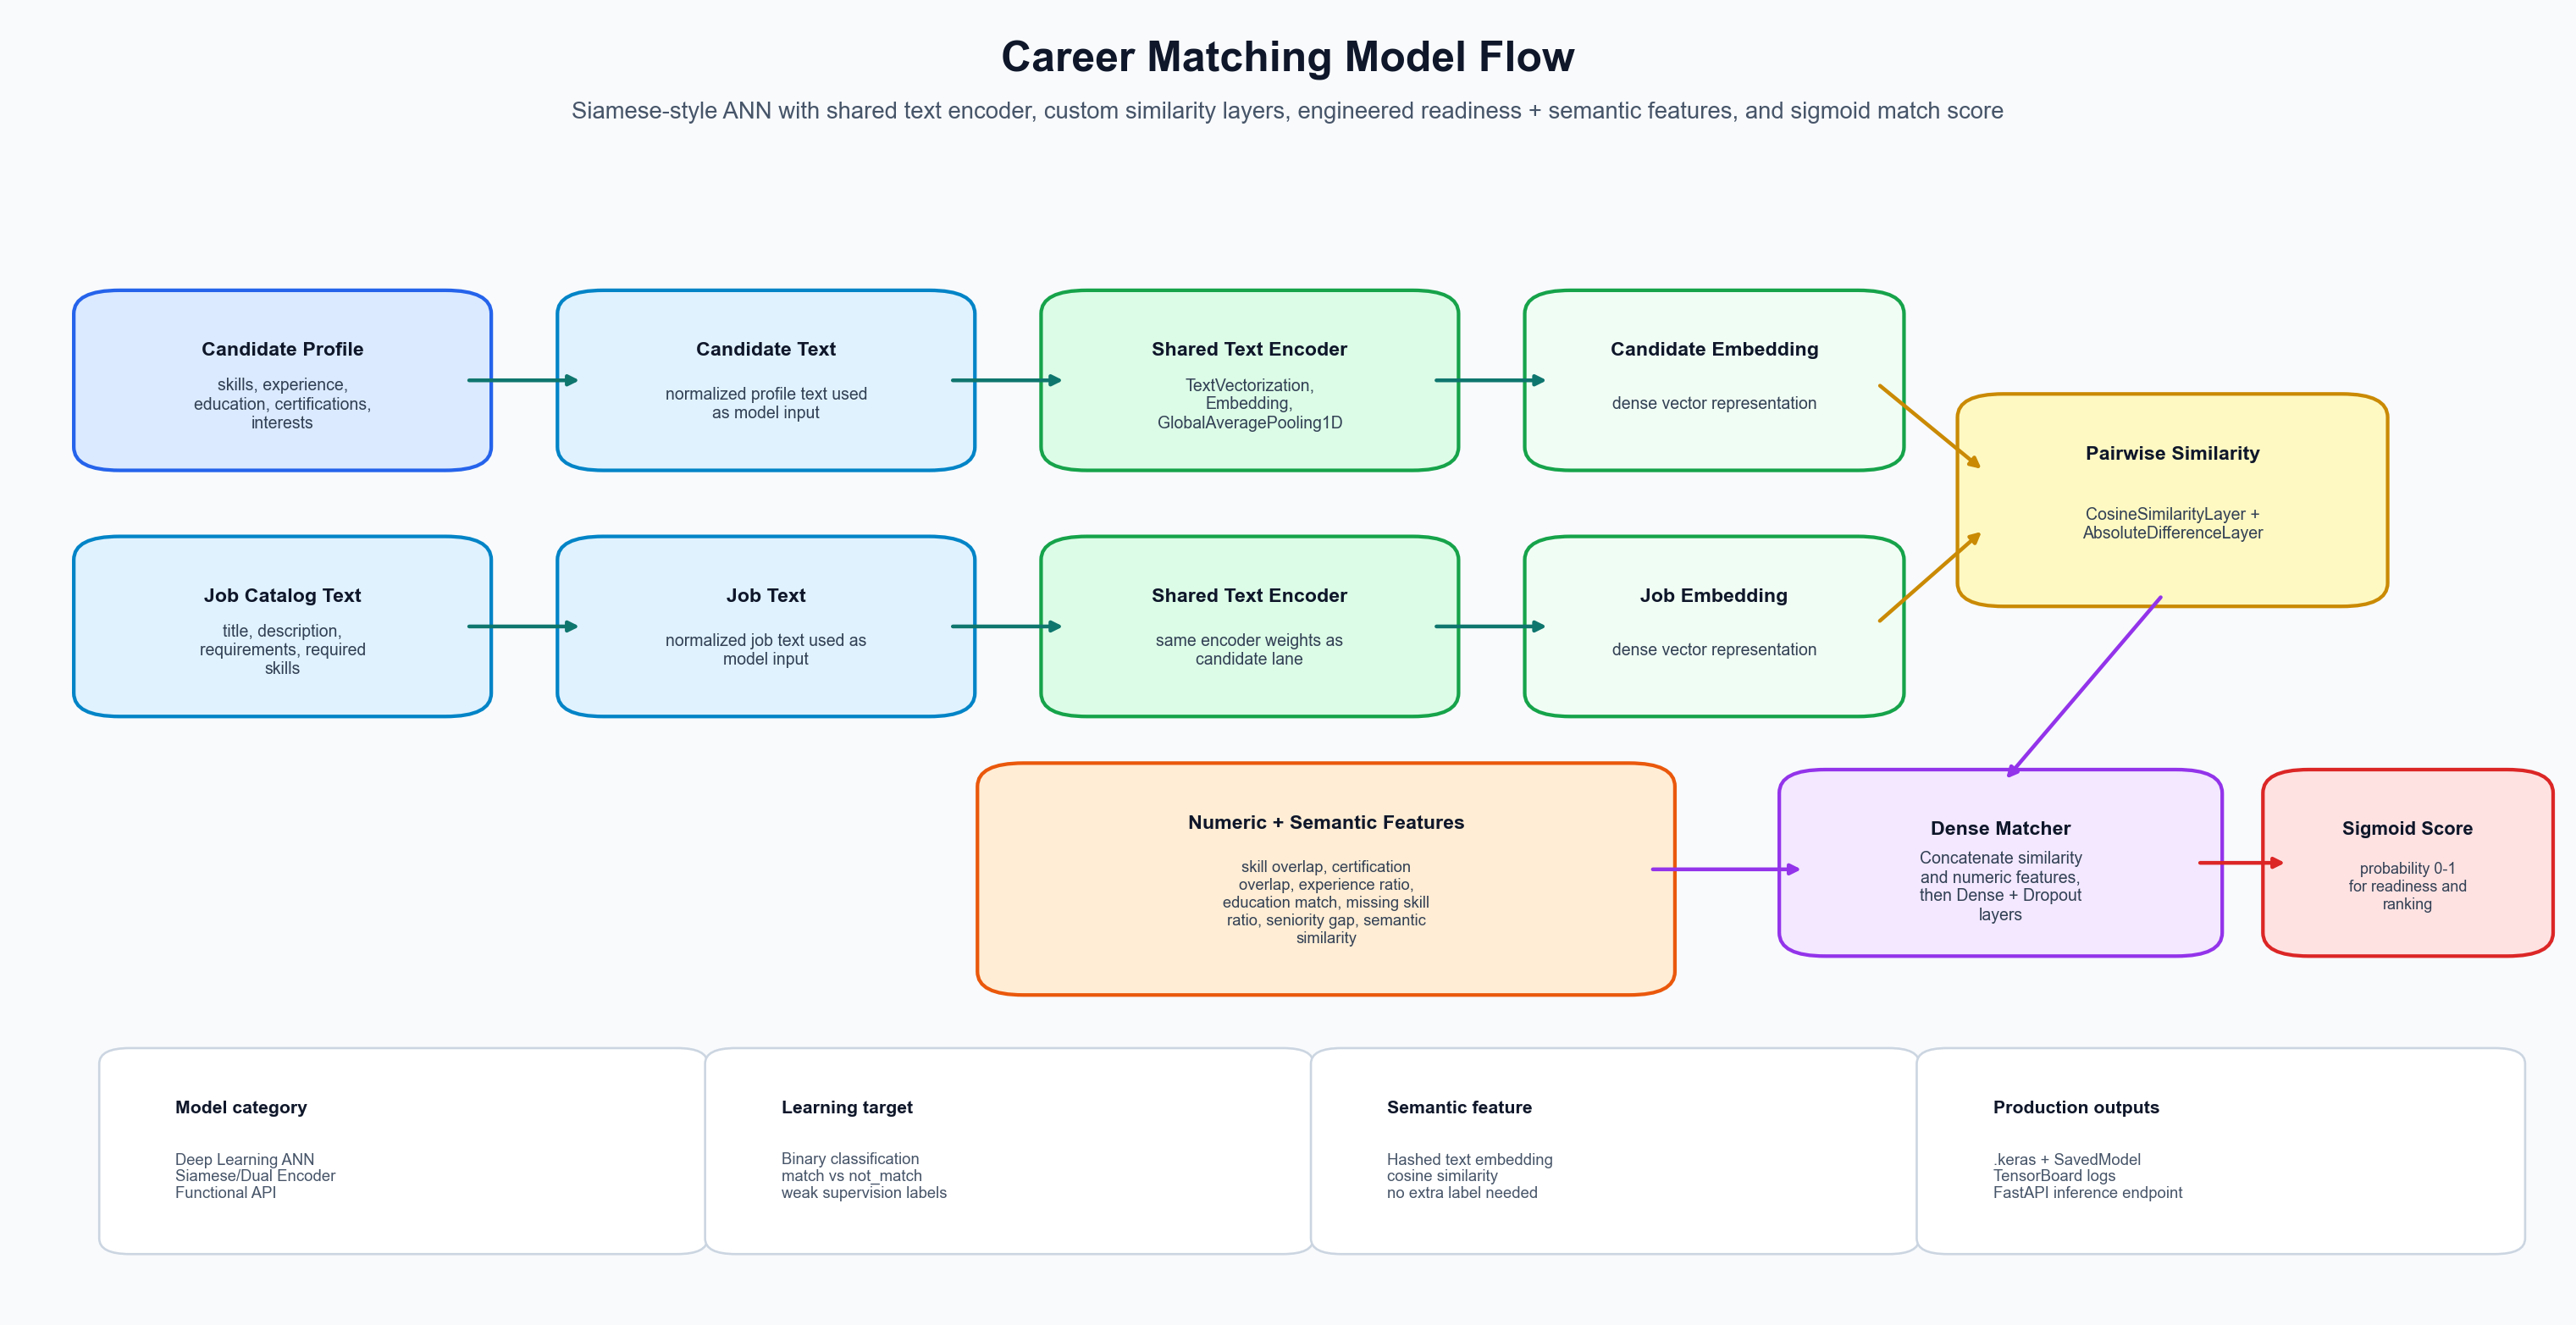

Diagram disimpan di: C:\DBS Foundation\CakapKarier AI\AIEngine\models\registry\career-match\v1\career_matching_model_flow.png


In [10]:
from pathlib import Path
from IPython.display import Image as IPImage, display as ipy_display
from matplotlib.patches import FancyBboxPatch


if 'show_figure' not in globals():
    def show_figure(fig, output_path=None, width=None, dpi=180):
        if output_path is not None:
            output_path = Path(output_path)
            output_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
            ipy_display(IPImage(filename=str(output_path), width=width))
        else:
            ipy_display(fig)
        plt.close(fig)

fig, ax = plt.subplots(figsize=(17, 8.8))
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('#f8fafc')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.text(
    0.5,
    0.965,
    'Career Matching Model Flow',
    ha='center',
    va='center',
    fontsize=20,
    fontweight='bold',
    color='#0f172a',
)
ax.text(
    0.5,
    0.925,
    'Siamese-style ANN with shared text encoder, custom similarity layers, engineered readiness + semantic features, and sigmoid match score',
    ha='center',
    va='center',
    fontsize=11,
    color='#475569',
)


def add_box(x, y, w, h, title, subtitle, face, edge, title_size=9.3, body_size=7.8, wrap_width=28):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        facecolor=face,
        edgecolor=edge,
        linewidth=1.7,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h - 0.034,
        title,
        ha='center',
        va='center',
        fontsize=title_size,
        fontweight='bold',
        color='#0f172a',
    )
    ax.text(
        x + w / 2,
        y + h / 2 - 0.018,
        '\n'.join(wrap(subtitle, wrap_width)),
        ha='center',
        va='center',
        fontsize=body_size,
        color='#334155',
        linespacing=1.22,
    )


def arrow(start, end, color='#0f766e', lw=1.8):
    ax.annotate(
        '',
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle='-|>', lw=lw, color=color, shrinkA=4, shrinkB=4),
    )

# Main two-lane model flow.
top_y = 0.66
bottom_y = 0.47
lane_h = 0.115
lane_w = 0.14

add_box(0.035, top_y, lane_w, lane_h, 'Candidate Profile', 'skills, experience, education, certifications, interests', '#dbeafe', '#2563eb')
add_box(0.225, top_y, lane_w, lane_h, 'Candidate Text', 'normalized profile text used as model input', '#e0f2fe', '#0284c7')
add_box(0.415, top_y, lane_w, lane_h, 'Shared Text Encoder', 'TextVectorization, Embedding, GlobalAveragePooling1D', '#dcfce7', '#16a34a')
add_box(0.605, top_y, 0.125, lane_h, 'Candidate Embedding', 'dense vector representation', '#f0fdf4', '#16a34a')

add_box(0.035, bottom_y, lane_w, lane_h, 'Job Catalog Text', 'title, description, requirements, required skills', '#e0f2fe', '#0284c7')
add_box(0.225, bottom_y, lane_w, lane_h, 'Job Text', 'normalized job text used as model input', '#e0f2fe', '#0284c7')
add_box(0.415, bottom_y, lane_w, lane_h, 'Shared Text Encoder', 'same encoder weights as candidate lane', '#dcfce7', '#16a34a')
add_box(0.605, bottom_y, 0.125, lane_h, 'Job Embedding', 'dense vector representation', '#f0fdf4', '#16a34a')

add_box(0.775, 0.555, 0.145, 0.14, 'Pairwise Similarity', 'CosineSimilarityLayer + AbsoluteDifferenceLayer', '#fef9c3', '#ca8a04', wrap_width=26)
add_box(0.39, 0.255, 0.25, 0.155, 'Numeric + Semantic Features', 'skill overlap, certification overlap, experience ratio, education match, missing skill ratio, seniority gap, semantic similarity', '#ffedd5', '#ea580c', body_size=7.35, wrap_width=32)
add_box(0.705, 0.285, 0.15, 0.12, 'Dense Matcher', 'Concatenate similarity and numeric features, then Dense + Dropout layers', '#f3e8ff', '#9333ea', wrap_width=25)
add_box(0.895, 0.285, 0.09, 0.12, 'Sigmoid Score', 'probability 0-1 for readiness and ranking', '#fee2e2', '#dc2626', title_size=8.8, body_size=7.2, wrap_width=17)

for y in [top_y, bottom_y]:
    cy = y + lane_h / 2
    arrow((0.175, cy), (0.225, cy))
    arrow((0.365, cy), (0.415, cy))
    arrow((0.555, cy), (0.605, cy))

arrow((0.73, top_y + lane_h / 2), (0.775, 0.645), color='#ca8a04')
arrow((0.73, bottom_y + lane_h / 2), (0.775, 0.605), color='#ca8a04')
arrow((0.845, 0.555), (0.78, 0.405), color='#9333ea')
arrow((0.64, 0.34), (0.705, 0.34), color='#9333ea')
arrow((0.855, 0.345), (0.895, 0.345), color='#dc2626')

# Compact technical summary band.
summary_y = 0.055
summary_h = 0.135
summary_items = [
    ('Model category', 'Deep Learning ANN\nSiamese/Dual Encoder\nFunctional API'),
    ('Learning target', 'Binary classification\nmatch vs not_match\nweak supervision labels'),
    ('Semantic feature', 'Hashed text embedding\ncosine similarity\nno extra label needed'),
    ('Production outputs', '.keras + SavedModel\nTensorBoard logs\nFastAPI inference endpoint'),
]

for idx, (label, value) in enumerate(summary_items):
    x = 0.045 + idx * 0.238
    note_box = FancyBboxPatch(
        (x, summary_y),
        0.215,
        summary_h,
        boxstyle='round,pad=0.012,rounding_size=0.012',
        facecolor='#ffffff',
        edgecolor='#cbd5e1',
        linewidth=1.05,
    )
    ax.add_patch(note_box)
    ax.text(x + 0.018, summary_y + summary_h - 0.038, label, fontsize=8.5, fontweight='bold', color='#0f172a')
    ax.text(x + 0.018, summary_y + 0.032, value, fontsize=7.4, color='#475569', linespacing=1.12)

plt.tight_layout()
flow_image_path = MODEL_DIR / 'career_matching_model_flow.png'
show_figure(fig, output_path=flow_image_path, width=1100)
print('Diagram disimpan di:', flow_image_path)





In [11]:

import tensorflow as tf

importlib.invalidate_caches()
modeling_module = importlib.import_module('career_match.modeling')
modeling_module = importlib.reload(modeling_module)
custom_objects = {
    'CosineSimilarityLayer': modeling_module.CosineSimilarityLayer,
    'AbsoluteDifferenceLayer': modeling_module.AbsoluteDifferenceLayer,
}

model = tf.keras.models.load_model(
    MODEL_DIR / 'career_match_model.keras',
    custom_objects=custom_objects,
    compile=False,
)

# Tabel arsitektur seperti contoh model.summary() Keras.
model.summary(line_length=120, expand_nested=True)

model_io = pd.DataFrame(
    [
        {
            'kind': 'input',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.inputs
    ]
    + [
        {
            'kind': 'output',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.outputs
    ]
)
display(model_io)


Model: "cakapkarier_career_matcher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ candidate_text (InputLayer)       │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ job_text (InputLayer)             │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ shared_text_encoder (Functional)  │ (None, 64)                   │           788,864 │ candidate_text[0][0],     
│                                   │                              │                   │ job_text[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text (InputLayer)            │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ career_text_vectorizer       │ (None, 160)                  │                 0 │ -                         
│ (TextVectorization)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ token_embedding (Embedding)  │ (None, 160, 96)              │           768,000 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ masked_average_pooling       │ (None, 96)                   │                 0 │ -                         
│ (GlobalAveragePooling1D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_layer_norm              │ (None, 96)                   │               192 │ -                         
│ (LayerNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dense_1 (Dense)         │ (None, 128)                  │            12,416 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dropout (Dropout)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_embedding (Dense)       │ (None, 64)                   │             8,256 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_abs_diff                │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│ (AbsoluteDifferenceLayer)         │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_product (Multiply)      │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│                                   │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼───────────────────

 Total params: 845,025 (3.22 MB)

 Trainable params: 844,705 (3.22 MB)

 Non-trainable params: 320 (1.25 KB)

,kind,name,shape,dtype
0,input,candidate_text,"(None,)",string
1,input,job_text,"(None,)",string
2,input,numeric_features,"(None, 8)",float32
3,output,keras_tensor_49,"(None, 1)",float32


## 6. Training, Evaluation, dan Export

Bagian ini menjalankan training model dan menyimpan artefak final yang siap dipakai oleh service inference. Secara default, notebook tidak menjalankan ulang training jika artefak model sudah tersedia. Untuk retraining, ubah `RUN_TRAINING=True` pada cell setup.

Training memenuhi checklist AI Engineer berikut:

- **TensorFlow Functional API** untuk membangun model multi-input: `candidate_text`, `job_text`, dan `numeric_features`.
- **Custom training loop** menggunakan `tf.GradientTape`, sehingga forward pass, loss calculation, gradient calculation, dan optimizer step dikontrol secara eksplisit.
- **Custom loss function** `CareerMatchLoss` untuk binary career matching.
- **Custom callback** `QualityThresholdCallback` untuk memantau target minimum akurasi dan MAE.
- **TensorBoard logging** untuk menyimpan metrik training dan validation per epoch.
- **Model export** ke `.keras` dan SavedModel agar bisa dipakai ulang oleh FastAPI service.

Metrik evaluasi yang dipakai:

- **Binary accuracy**: persentase prediksi `match` dan `not_match` yang benar.
- **MAE**: rata-rata selisih probabilitas prediksi terhadap label.
- **Loss**: kualitas optimisasi selama training.
- **Classification report**: precision, recall, dan f1-score per kelas.
- **Confusion matrix**: ringkasan prediksi benar dan salah.
- **Epoch duration**: waktu training per epoch untuk menjelaskan efisiensi eksperimen.

Catatan interpretasi: metrik tinggi pada dataset weak supervision menunjukkan model berhasil mempelajari aturan label yang dibangun secara konsisten. Untuk menghindari skor web terlalu kaku terhadap profil nyata, service inference memakai calibrated readiness score. Dengan demikian, output UI tidak hanya bergantung pada raw sigmoid probability, tetapi juga pada sinyal interpretable seperti skill, pengalaman, sertifikasi, dan semantic similarity.


In [12]:

from argparse import Namespace

importlib.invalidate_caches()
train_module = importlib.import_module('pipelines.train_model')
train_module = importlib.reload(train_module)

if RUN_TRAINING or not (MODEL_DIR / 'career_match_model.keras').exists():
    train_args = Namespace(
        processed_dir=PROCESSED_DIR,
        model_dir=MODEL_DIR,
        epochs=20,
        min_epochs=5,
        batch_size=64,
        learning_rate=0.0015,
        max_tokens=8000,
        sequence_length=160,
        embedding_dim=96,
        dropout=0.18,
        seed=42,
        min_accuracy=0.85,
        max_mae=0.02,
        skip_threshold_check=False,
    )
    training_metadata = train_module.run_training(train_args)
else:
    training_metadata = json.loads((MODEL_DIR / 'metadata.json').read_text(encoding='utf-8'))
    print('Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.')
    print('Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.')

training_metadata['metrics']


Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.
Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.


{'train': {'loss': 0.0027411743067204952,
  'binary_accuracy': 0.9975615739822388,
  'mae': 0.01132167037576437},
 'validation': {'loss': 0.0023141440469771624,
  'binary_accuracy': 0.9988623261451721,
  'mae': 0.004473348148167133},
 'test': {'loss': 0.0052447207272052765,
  'binary_accuracy': 0.997724711894989,
  'mae': 0.004963076673448086},
 'thresholds': {'min_accuracy': 0.85, 'max_mae': 0.02},
 'threshold_callback_reached_epoch': 5,
 'training_time': {'epochs_ran': 5,
  'total_epoch_seconds': 188.636,
  'mean_epoch_seconds': 37.727,
  'last_epoch_seconds': 37.647}}

In [13]:
metrics = json.loads((MODEL_DIR / 'metrics.json').read_text(encoding='utf-8'))
metrics_table = pd.DataFrame(
    [
        {'split': split, **metrics[split]}
        for split in ['train', 'validation', 'test']
    ]
)
display(metrics_table)

test_accuracy = metrics['test']['binary_accuracy']
test_mae = metrics['test']['mae']
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print('Target accuracy >= 0.85:', test_accuracy >= 0.85)
print('Target MAE <= 0.02:', test_mae <= 0.02)

,split,loss,binary_accuracy,mae
0,train,0.002741,0.997562,0.011322
1,validation,0.002314,0.998862,0.004473
2,test,0.005245,0.997725,0.004963


Test accuracy: 0.9977
Test MAE: 0.0050
Target accuracy >= 0.85: True
Target MAE <= 0.02: True


## Classification Report dan Confusion Matrix

Evaluasi berikut memakai test set. Karena model ini adalah binary career matching, kelasnya adalah `not_match` dan `match`.

Cara membaca metrik:

- **Precision** menunjukkan seberapa banyak prediksi pada suatu kelas yang benar. Precision tinggi pada kelas `match` berarti model jarang salah menyatakan kandidat cocok.
- **Recall** menunjukkan seberapa banyak data aktual pada suatu kelas yang berhasil ditemukan. Recall tinggi pada kelas `match` berarti model mampu menangkap sebagian besar kandidat yang seharusnya cocok.
- **F1-score** adalah rata-rata harmonis precision dan recall, sehingga cocok dipakai untuk melihat keseimbangan precision dan recall.
- **Support** menunjukkan jumlah data test pada masing-masing kelas.
- **Accuracy** menunjukkan rasio prediksi benar dari seluruh data test.

Confusion matrix digunakan sebagai visual pendukung untuk melihat jumlah prediksi benar dan salah. Nilai diagonal menunjukkan prediksi benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi.

Hal yang perlu disampaikan saat presentasi: hasil test set membuktikan pipeline weak supervision, training, dan export sudah berjalan konsisten. Namun angka ini tidak boleh dibaca sebagai jaminan bahwa model selalu 99 persen benar untuk semua user nyata. Untuk MVP, angka tersebut cukup untuk memenuhi target teknis. Untuk validasi bisnis jangka panjang, perlu tambahan manual review, feedback user, atau data outcome independen.


              precision    recall  f1-score   support

   not_match       1.00      1.00      1.00      1758
       match       0.99      1.00      1.00       879

    accuracy                           1.00      2637
   macro avg       1.00      1.00      1.00      2637
weighted avg       1.00      1.00      1.00      2637



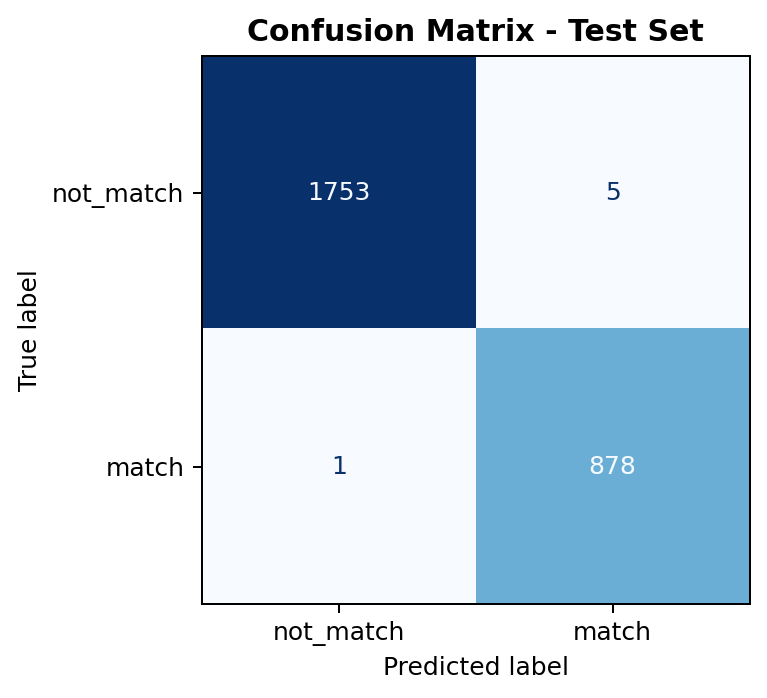

In [14]:
classification_report_txt = MODEL_DIR / 'classification_report.txt'
classification_report_csv = MODEL_DIR / 'classification_report.csv'
confusion_matrix_image = MODEL_DIR / 'confusion_matrix.png'

if classification_report_txt.exists():
    print(classification_report_txt.read_text(encoding='utf-8'))
elif classification_report_csv.exists():
    report_df = pd.read_csv(classification_report_csv)
    display(report_df.round(4))
else:
    print('classification_report.txt belum tersedia. Jalankan training terlebih dahulu.')

if confusion_matrix_image.exists():
    ipy_display(IPImage(filename=str(confusion_matrix_image), width=380))
else:
    print('confusion_matrix.png belum tersedia.')



,epoch,epoch_duration_seconds,epoch_duration_minutes,loss,binary_accuracy,mae,val_loss,val_binary_accuracy,val_mae,val_accuracy_target_met,val_mae_target_met
0,1,40.54140,0.67569,0.01120,0.99025,0.04055,0.04435,0.96890,0.16457,True,False
1,2,33.12113,0.55202,0.00364,0.99716,0.01717,0.00218,0.99886,0.03133,True,False
2,3,39.96160,0.66603,0.00322,0.99805,0.01445,0.00122,0.99848,0.00984,True,True
3,4,37.36499,0.62275,0.00358,0.99829,0.00978,0.00314,0.99772,0.00483,True,True
4,5,37.64667,0.62744,0.00274,0.99756,0.01132,0.00231,0.99886,0.00447,True,True


Total waktu epoch training: 188.64 detik (3.14 menit)
Rata-rata waktu per epoch: 37.73 detik


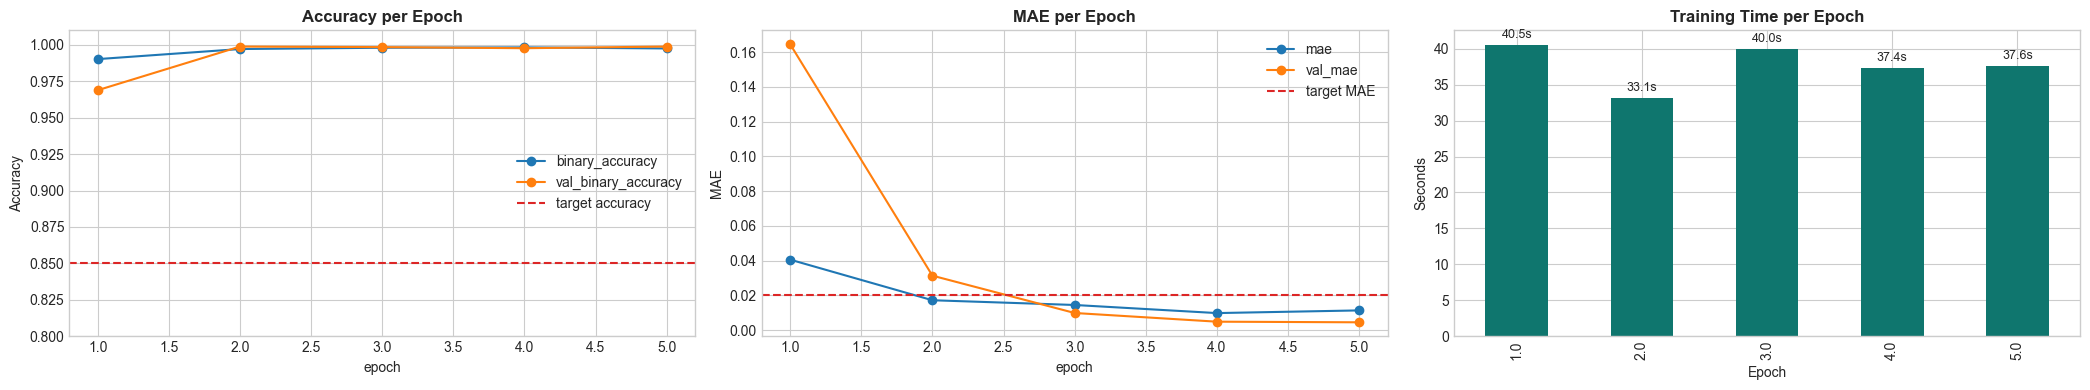

In [15]:
history_path = MODEL_DIR / 'training_history.csv'
history_df = pd.read_csv(history_path)
epoch_log = history_df.copy()
epoch_log['epoch'] = epoch_log['epoch'].astype(int)
epoch_log['val_accuracy_target_met'] = epoch_log['val_binary_accuracy'] >= 0.85
epoch_log['val_mae_target_met'] = epoch_log['val_mae'] <= 0.02

if 'epoch_duration_seconds' in epoch_log.columns:
    epoch_log['epoch_duration_minutes'] = epoch_log['epoch_duration_seconds'] / 60

ordered_columns = [
    'epoch',
    'epoch_duration_seconds',
    'epoch_duration_minutes',
    'loss',
    'binary_accuracy',
    'mae',
    'val_loss',
    'val_binary_accuracy',
    'val_mae',
    'val_accuracy_target_met',
    'val_mae_target_met',
]
ordered_columns = [column for column in ordered_columns if column in epoch_log.columns]
display(epoch_log[ordered_columns].round(5))

if 'epoch_duration_seconds' in history_df.columns:
    total_seconds = history_df['epoch_duration_seconds'].sum()
    mean_seconds = history_df['epoch_duration_seconds'].mean()
    print(f'Total waktu epoch training: {total_seconds:.2f} detik ({total_seconds / 60:.2f} menit)')
    print(f'Rata-rata waktu per epoch: {mean_seconds:.2f} detik')

try:
    figure_count = 3 if 'epoch_duration_seconds' in history_df.columns else 2
    fig, axes = plt.subplots(1, figure_count, figsize=(7 * figure_count, 4))
    if figure_count == 1:
        axes = [axes]

    history_df.plot(x='epoch', y=['binary_accuracy', 'val_binary_accuracy'], marker='o', ax=axes[0])
    axes[0].axhline(0.85, color='#dc2626', linestyle='--', label='target accuracy')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_ylim(0.8, 1.01)
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    history_df.plot(x='epoch', y=['mae', 'val_mae'], marker='o', ax=axes[1])
    axes[1].axhline(0.02, color='#dc2626', linestyle='--', label='target MAE')
    axes[1].set_title('MAE per Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    if 'epoch_duration_seconds' in history_df.columns:
        history_df.plot(x='epoch', y='epoch_duration_seconds', kind='bar', color='#0f766e', ax=axes[2], legend=False)
        axes[2].set_title('Training Time per Epoch')
        axes[2].set_ylabel('Seconds')
        axes[2].set_xlabel('Epoch')
        for container in axes[2].containers:
            axes[2].bar_label(container, fmt='%.1fs', padding=3, fontsize=9)

    plt.tight_layout()
    show_figure(fig)
except Exception as exc:
    print('Plot dilewati:', exc)



## 7. Exported Artifacts

Bagian ini menampilkan file hasil training dan evaluasi yang disimpan di model registry. Artefak ini menjadi bukti bahwa model tidak hanya berjalan di notebook, tetapi juga dapat dimuat ulang oleh service inference.

Artefak utama:

- **`career_match_model.keras`**: model TensorFlow/Keras utama dalam format siap load ulang.
- **`saved_model/`**: format TensorFlow SavedModel untuk kebutuhan serving atau deployment lanjutan.
- **`metadata.json`**: informasi versi model, lokasi artefak, konfigurasi training, fitur input, dan metrik akhir.
- **`metrics.json`**: ringkasan metrik train, validation, test, dan durasi epoch.
- **`training_history.csv`**: riwayat metrik per epoch.
- **`classification_report.txt`**: laporan precision, recall, f1-score, support, dan accuracy pada test set.
- **`confusion_matrix.png`**: visualisasi klasifikasi benar dan salah.
- **`jobs_catalog.json`**: katalog lowongan yang dipakai saat inference untuk mencari top matches.
- **`tensorboard/`**: log TensorBoard untuk memantau metrik training dan validation.

Dengan artefak ini, backend tidak perlu menjalankan ulang notebook atau training. Backend cukup menjalankan FastAPI service yang memuat model, metadata, dan job catalog dari registry. Jika artefak model diperbarui, service AI perlu direstart agar model yang tersimpan di memory ikut terganti.


,artifact,exists,size_mb
0,models\registry\career-match\v1\career_match_m...,True,3.455
1,models\registry\career-match\v1\saved_model,True,6.793
2,models\registry\career-match\v1\jobs_catalog.json,True,15.131
3,models\registry\career-match\v1\metrics.json,True,0.001
4,models\registry\career-match\v1\tensorboard,True,0.002


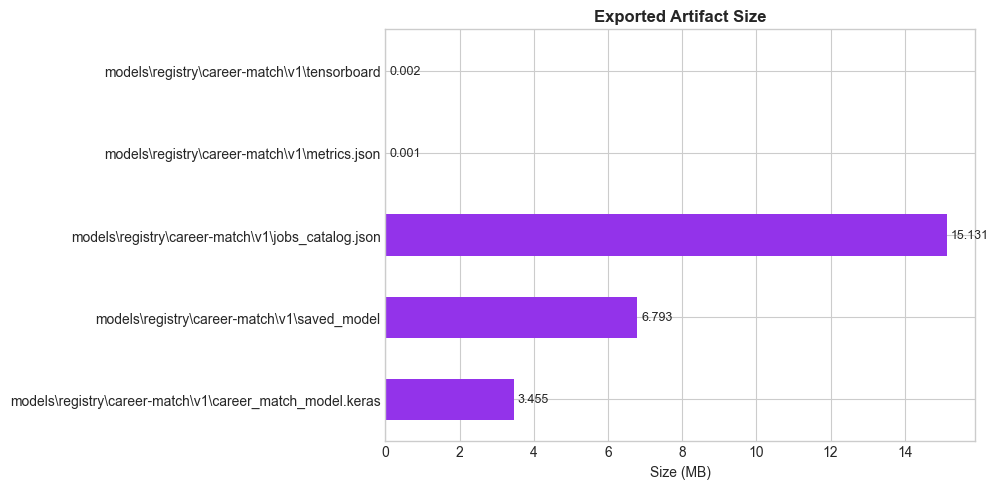

In [16]:
artifact_rows = []
for path in [
    MODEL_DIR / 'career_match_model.keras',
    MODEL_DIR / 'saved_model',
    MODEL_DIR / 'jobs_catalog.json',
    MODEL_DIR / 'metrics.json',
    MODEL_DIR / 'tensorboard',
]:
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
    elif path.is_dir():
        size_mb = sum(item.stat().st_size for item in path.rglob('*') if item.is_file()) / (1024 * 1024)
    else:
        size_mb = 0
    artifact_rows.append({'artifact': str(path.relative_to(AIENGINE_ROOT)), 'exists': path.exists(), 'size_mb': round(size_mb, 3)})

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

ax = artifact_df.set_index('artifact')['size_mb'].plot(kind='barh', color='#9333ea')
ax.set_title('Exported Artifact Size')
ax.set_xlabel('Size (MB)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
show_figure(ax.figure)


## 8. Inference Demo

Bagian ini menunjukkan simulasi penggunaan model setelah training selesai. Tujuannya adalah membuktikan bahwa model dapat menerima profil kandidat dan menghasilkan rekomendasi yang bisa dipakai oleh aplikasi web.

Alur inference:

1. User mengirim profil: skill, pengalaman, pendidikan, sertifikasi, target role, minat/bakat, dan lokasi preferensi.
2. Service membentuk `candidate_text`, melakukan normalisasi skill, dan membuat fitur numerik kandidat.
3. Kandidat dibandingkan dengan seluruh lowongan di `jobs_catalog.json`.
4. Model menghasilkan raw sigmoid probability untuk setiap pasangan kandidat-lowongan.
5. Service menghitung calibrated readiness score dengan menggabungkan probabilitas model dan fitur interpretable.
6. Lowongan diurutkan berdasarkan skor akhir yang sudah dikalibrasi.
7. Output dikemas menjadi JSON response untuk frontend.

Output yang relevan untuk produk:

- **Predicted role**: role atau lowongan paling relevan berdasarkan ranking akhir.
- **Readiness score**: skor kesiapan kandidat dalam skala 0 sampai 100. Ini adalah skor utama untuk UI.
- **Readiness status**: kategori kesiapan seperti `Siap`, `Cukup Siap`, atau `Perlu Ditingkatkan`.
- **Top matches**: daftar lowongan paling cocok dengan `match_score` dan `readiness_percentage`.
- **Model probability**: probabilitas mentah dari model, disediakan untuk debugging dan audit, bukan skor utama UI.
- **Readiness features**: breakdown fitur seperti skill overlap, pengalaman, pendidikan, dan semantic similarity.
- **Matched skills dan skill gap**: dasar rekomendasi belajar.
- **Roadmap dan recommendations**: saran tindakan yang dapat ditampilkan ke pengguna.

Demo ini menjembatani model AI dengan kebutuhan tim fullstack karena response inference sudah menyerupai format yang dibutuhkan oleh aplikasi web.


In [17]:

importlib.invalidate_caches()
inference_module = importlib.import_module('career_match.inference')
inference_module = importlib.reload(inference_module)
CareerMatchService = inference_module.CareerMatchService

service = CareerMatchService(MODEL_DIR)
prediction = service.predict(
    skills=['Python', 'SQL', 'Machine Learning', 'Data Analysis', 'TensorFlow'],
    experience_years=2,
    education_level='bachelor',
    certifications=['TensorFlow Developer'],
    preferred_location='Jakarta',
    top_k=5,
)
prediction


{'predicted_role': 'Tenaga Pengajar It',
 'target_role': None,
 'role_family': 'design-content',
 'readiness_score': 78.97,
 'readiness_status': 'Cukup Siap',
 'match_confidence': 0.7897,
 'numeric_features': ['skill_overlap',
  'certification_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap',
  'semantic_similarity'],
 'top_matches': [{'job_id': 'glints-1779166796-520',
   'job_title': 'Tenaga Pengajar It',
   'company': 'Digikidz',
   'location': 'Jakarta Selatan, Dki Jakarta',
   'job_detail': 'https://glints.com/id/opportunities/jobs/tenaga-pengajar-it/ae88950c-fc93-46b3-b15e-11e6a46cd9f8?utm_referrer=explore&traceInfo=5dca10c6a731f85c9d77ce3ef009c3ba',
   'role_family': 'design-content',
   'work_mode': 'unknown',
   'required_experience_years': 1.0,
   'required_education': 'diploma',
   'match_score': 0.7897,
   'readiness_percentage': 78.97,
   'model_probability': 0.9012,
   'target_alignment': 0,
   'readine

,job_id,job_title,company,location,job_detail,role_family,work_mode,required_experience_years,required_education,match_score,readiness_percentage,model_probability,target_alignment,readiness_features,matched_skills,missing_skills
0,glints-1779166796-520,Tenaga Pengajar It,Digikidz,"Jakarta Selatan, Dki Jakarta",https://glints.com/id/opportunities/jobs/tenag...,design-content,unknown,1.0,diploma,0.7897,78.97,0.9012,0,"{'skill_overlap': 0.8, 'certification_overlap'...","[machine learning, python]",[pytorch]
1,glints-1779200309-288,Tenaga Pengajar It,Digikidz,"Jakarta Selatan, Dki Jakarta",https://glints.com/id/opportunities/jobs/tenag...,design-content,unknown,1.0,diploma,0.7897,78.97,0.9012,0,"{'skill_overlap': 0.8, 'certification_overlap'...","[machine learning, python]",[pytorch]
2,linkedin-Not Available,Machine Learning Researcher,Crossing Hurdles,Indonesia,Not Available,data-ai,unknown,0.0,not specified,0.7800,78.00,0.9797,0,"{'skill_overlap': 1.0, 'certification_overlap'...","[tensorflow, machine learning]",[]
3,linkedin-Not Available,Software Engineer - Python & Go,Crossing Hurdles,Indonesia,Not Available,software-engineering,unknown,0.0,not specified,0.7800,78.00,0.9108,0,"{'skill_overlap': 1.0, 'certification_overlap'...",[python],[]
4,linkedin-Not Available,Python Developer,Crossing Hurdles,Indonesia,Not Available,other-it,unknown,0.0,not specified,0.7800,78.00,0.8764,0,"{'skill_overlap': 1.0, 'certification_overlap'...",[python],[]


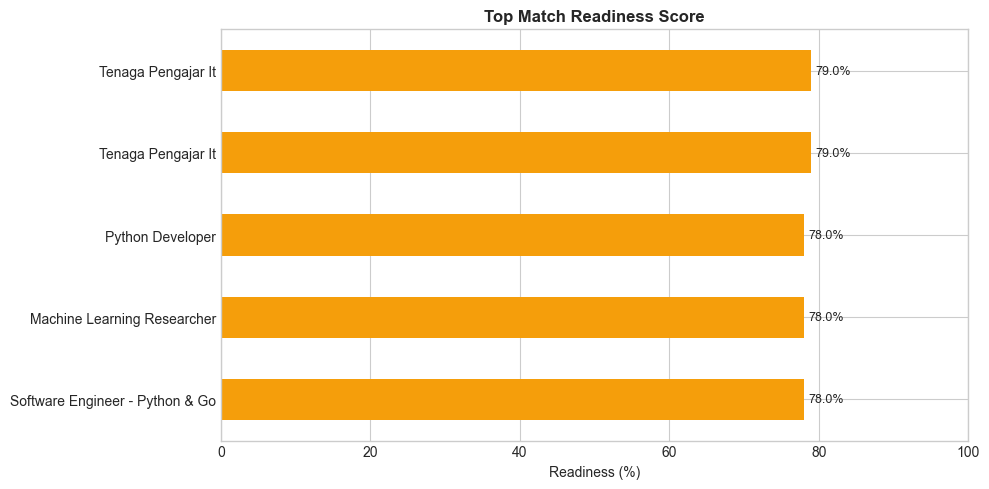

Predicted role: Tenaga Pengajar It
Readiness score: 78.97
Skill gap: ['pytorch']
Recommendations:
- Bangun bukti portofolio untuk pytorch lewat mini project, latihan studi kasus, dan sertifikasi dasar.


In [18]:
top_matches_df = pd.DataFrame(prediction['top_matches'])
display(top_matches_df)

plot_df = top_matches_df.sort_values('readiness_percentage')
colors = ['#16a34a' if value >= 85 else '#f59e0b' if value >= 70 else '#dc2626' for value in plot_df['readiness_percentage']]
ax = plot_df.plot(kind='barh', x='job_title', y='readiness_percentage', legend=False, color=colors, figsize=(10, 5))
ax.set_title('Top Match Readiness Score')
ax.set_xlabel('Readiness (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
show_figure(ax.figure)

print('Predicted role:', prediction['predicted_role'])
print('Readiness score:', prediction['readiness_score'])
print('Skill gap:', prediction['skill_gap'])
print('Recommendations:')
for item in prediction['recommendations']:
    print('-', item)


## 9. REST API Contract

FastAPI service disediakan agar model dapat dipakai oleh aplikasi tanpa menjalankan notebook. Service memuat model dari registry, membaca job catalog, melakukan preprocessing input user, menjalankan inference, mengalibrasi readiness score, lalu mengembalikan response dalam format JSON.

Jalankan dari folder `AIEngine`:

```bash
uvicorn career_match.app:app --app-dir services/career-match/src --host 127.0.0.1 --port 8001
```

Endpoint utama:

- **`GET /health`**: mengecek apakah service dan model tersedia.
- **`GET /genai/health`**: mengecek status provider GenAI optional, dalam project ini menggunakan Ollama/OpenAI-compatible API.
- **`POST /predict`**: endpoint inference utama dengan schema AI Engine.
- **`POST /predict/web`**: endpoint adapter untuk integrasi dengan form dari WebApplication.

Input penting yang perlu disiapkan frontend/backend:

- **Skill**: daftar skill yang dikuasai kandidat.
- **Pengalaman**: jumlah tahun pengalaman atau teks pengalaman.
- **Sertifikasi**: daftar sertifikasi kandidat, boleh kosong jika belum ada.
- **Pendidikan**: pendidikan terakhir kandidat.
- **Target role**: role yang ingin dituju, misalnya Backend Developer, Front-End Developer, Data Scientist, atau AI Engineer.
- **Preferred location**: lokasi preferensi kandidat, jika tersedia.
- **use_genai**: opsi untuk mengaktifkan ringkasan GenAI, jika provider tersedia.

Response utama yang dikembalikan service:

- `predicted_role`
- `target_role`
- `role_family`
- `readiness_score`
- `readiness_status`
- `match_confidence`
- `top_matches`
- `mastered_skills`
- `skill_gap`
- `skill_gap_analysis`
- `roadmap`
- `recommendations`
- `tips`
- `ai_summary`

Kontrak lengkap tersedia di `AIEngine/shared/schemas/career_match_contract.json`. File ini menjadi acuan bersama antara AI Engineer dan tim fullstack agar integrasi tidak bergantung pada asumsi informal.


In [19]:
contract_path = AIENGINE_ROOT / 'shared' / 'schemas' / 'career_match_contract.json'
contract = json.loads(contract_path.read_text(encoding='utf-8'))
contract

{'service': 'career-match',
 'version': '1.4.1',
 'endpoints': {'health': 'GET /health',
  'genai_health': 'GET /genai/health',
  'predict': 'POST /predict',
  'predict_web': 'POST /predict/web'},
 'request': {'skills': {'type': 'array<string>|string',
   'required': True,
   'description': 'Daftar skill kandidat. Untuk /predict disarankan array; /predict/web boleh string dipisah koma.'},
  'experience_years': {'type': 'number',
   'required': 'true for /predict, optional for /predict/web',
   'min': 0,
   'max': 60},
  'education_level': {'type': 'string|integer',
   'required': False,
   'examples': ['sma', 'd3', 's1', 'diploma', 'bachelor', 'master', 3]},
  'certifications': {'type': 'array<string>|string',
   'required': 'true for /predict, optional for /predict/web',
   'description': 'Daftar sertifikasi kandidat. Kirim array kosong jika kandidat belum memiliki sertifikasi.'},
  'interests': {'type': 'array<string>|string|null',
   'required': False,
   'description': 'Minat dan b

## 10. Backend Handoff untuk Update v1.4.1

Bagian ini merangkum hal yang perlu diambil oleh tim backend setelah update model dan scoring.

Perubahan penting:

- Endpoint utama tetap **`POST /predict/web`**, sehingga form web tidak perlu mengganti endpoint.
- Versi kontrak AI Engine saat ini adalah **`1.4.1`**.
- Request body tetap mendukung alias dari WebApplication, seperti `pendidikan_terakhir`, `skill_yang_dikuasai`, `minat_bakat`, `pengalaman_sertifikasi`, `sertifikasi`, dan `target_skill_role`.
- Skor yang harus ditampilkan ke user adalah `readiness_score`, `match_confidence`, `top_matches[].match_score`, atau `top_matches[].readiness_percentage`.
- Field `top_matches[].model_probability` adalah raw sigmoid probability dari model. Field ini sebaiknya hanya dipakai untuk debugging atau audit, bukan untuk tampilan utama ke user.
- Field `top_matches[].readiness_features` dapat dipakai jika frontend ingin membuat penjelasan skor, misalnya menampilkan kontribusi skill overlap, pengalaman, pendidikan, sertifikasi, semantic similarity, `certification_required_overlap`, dan `certification_completeness_boost`.
- Setelah AI Engine di-update, service FastAPI perlu direstart karena model dan job catalog dimuat ke memory saat service berjalan.

Field response yang direkomendasikan untuk UI:

| Kebutuhan UI | Field dari AI Engine | Catatan |
|---|---|---|
| Skor utama kesiapan | `readiness_score` | Skala 0-100, sudah dikalibrasi |
| Status kesiapan | `readiness_status` | `Siap`, `Cukup Siap`, atau `Perlu Ditingkatkan` |
| Confidence ringkas | `match_confidence` | Skala 0-1, mengikuti skor readiness terkalibrasi |
| Daftar lowongan cocok | `top_matches` | Pakai `match_score` atau `readiness_percentage` |
| Skill yang sudah sesuai | `mastered_skills` | Bisa ditampilkan sebagai badge/chips |
| Skill gap | `skill_gap` dan `skill_gap_analysis` | Dipakai untuk rekomendasi belajar |
| Roadmap belajar | `roadmap` | Berisi fase dan item pembelajaran |
| Rekomendasi praktis | `recommendations` dan `tips` | Saran tambahan untuk user |
| Ringkasan GenAI optional | `ai_summary` | Muncul jika `use_genai=true` dan provider tersedia |

Checklist integrasi backend:

1. Pull/update folder `AIEngine` terbaru, termasuk `services/career-match/`, `shared/schemas/`, dan `models/registry/career-match/v1/`.
2. Pastikan environment backend mengarah ke `AI_CAREER_MATCH_URL=http://127.0.0.1:8001` atau host AI service yang digunakan.
3. Jalankan ulang FastAPI AI service.
4. Backend tetap memanggil `POST /predict/web`.
5. Frontend menampilkan calibrated score, bukan `model_probability`.
6. Simpan `model_probability` dan `readiness_features` hanya jika dibutuhkan untuk debugging atau monitoring internal.


## 11. TensorBoard

TensorBoard digunakan untuk memantau proses training secara visual. Log TensorBoard disimpan di model registry sehingga metrik training tetap tersedia sebagai artefak repository akhir.

Informasi yang bisa dilihat di TensorBoard:

- **Training loss**: apakah model semakin baik meminimalkan error selama training.
- **Validation loss**: apakah performa pada data validasi ikut membaik atau justru memburuk.
- **Binary accuracy**: akurasi model pada data train dan validation per epoch.
- **MAE**: rata-rata error probabilitas prediksi terhadap label.
- **Epoch duration**: waktu yang dibutuhkan setiap epoch.

Jika training dijalankan beberapa kali, TensorBoard dapat menampilkan lebih dari satu event file. Itu normal karena setiap proses training membuat log baru. Untuk demo final, cukup gunakan run terakhir atau kosongkan folder TensorBoard sebelum retraining final.

Jalankan dari folder `AIEngine`:

```bash
tensorboard --logdir models/registry/career-match/v1/tensorboard --port 6006
```

Lalu buka browser ke:

```text
http://localhost:6006
```

Tab yang paling relevan untuk project ini adalah **Scalars**, karena metrik model disimpan sebagai scalar per epoch. Jika TensorBoard menampilkan pesan tidak ada scalar data, pastikan path `--logdir` mengarah ke folder `models/registry/career-match/v1/tensorboard` dari dalam folder `AIEngine`.


,run,file,size_kb,last_modified
0,train,events.out.tfevents.1779451158.ASUS-TUF-A15.19...,1.42,1.779451e+09
1,validation,events.out.tfevents.1779451158.ASUS-TUF-A15.19...,1.09,1.779451e+09


,file_count,total_size_kb
run,,
train,1,1.42
validation,1,1.09


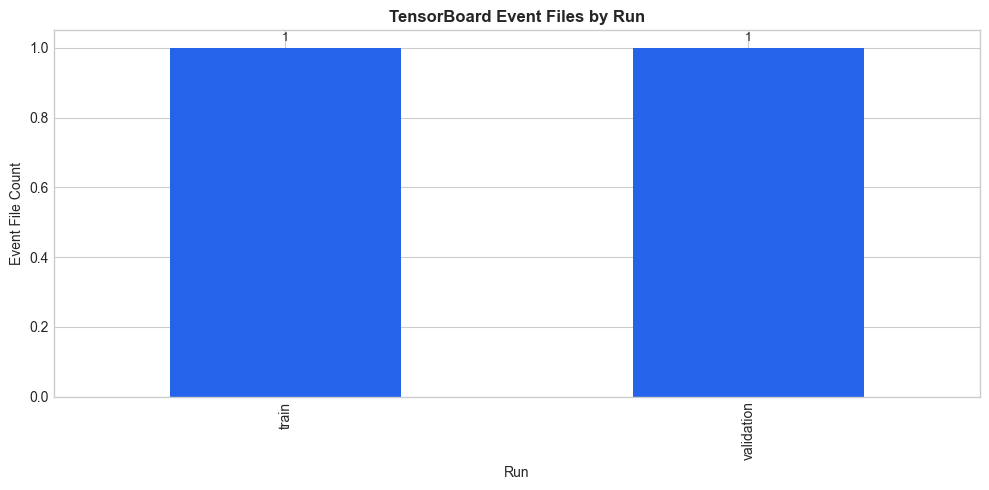

In [20]:
event_files = []
for path in (MODEL_DIR / 'tensorboard').rglob('events.out.tfevents*'):
    event_files.append(
        {
            'run': path.parent.name,
            'file': path.name,
            'size_kb': round(path.stat().st_size / 1024, 2),
            'last_modified': path.stat().st_mtime,
        }
    )

event_df = pd.DataFrame(event_files).sort_values(['run', 'file'])
display(event_df)

if not event_df.empty:
    summary_df = event_df.groupby('run').agg(file_count=('file', 'count'), total_size_kb=('size_kb', 'sum'))
    display(summary_df)
    ax = summary_df['file_count'].plot(kind='bar', color='#2563eb')
    ax.set_title('TensorBoard Event Files by Run')
    ax.set_xlabel('Run')
    ax.set_ylabel('Event File Count')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    show_figure(ax.figure)
